In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

# A/B тестирование двух разных моделей

Данные собраны синтетически (Файлы из заданий курса). То есть, результаты этого тестирования не будут совпадать с моим моделями.

In [2]:
df_views = pd.read_csv('views.csv')

In [3]:
df_views.head()

,user_id,exp_group,recommendations,timestamp
0,128381,control,[3644 4529 4704 5294 4808],1654030803
1,146885,test,[1399 1076 797 7015 5942],1654030811
2,50948,test,[2315 3037 1861 6567 4093],1654030825
3,37703,test,[2842 1949 162 1588 6794],1654030826
4,14661,test,[2395 5881 5648 3417 673],1654030829


In [4]:
df_views.shape

(193295, 4)

In [5]:
df_likes = pd.read_csv('likes.csv')

In [6]:
df_likes.head()

,user_id,post_id,timestamp
0,128381,4704,1654030804
1,146885,1399,1654030816
2,50948,2315,1654030828
3,14661,673,1654030831
4,37703,1588,1654030833


In [7]:
df_likes.shape

(230176, 3)

### Подготовка данных

Начнём с проверки разбиения групп.

Во-первых, у нас нет таблички соответствия пользователь-группа, так как мы на самом деле определяли группу пользователя прямо перед подготовкой рекомендаций.

Нужно:
1. Проверить, нету ли совпадений в группе (Нет ли пользователей, которые относятся к 2 группам сразу)
2. Создать таблицу "Пользователь-Группа"

In [8]:
# Получаем множества user_id для каждой группы
control_users = set(df_views[df_views['exp_group'] == 'control']['user_id'])
test_users = set(df_views[df_views['exp_group'] == 'test']['user_id'])

# Находим пересечение
users_in_both = control_users.intersection(test_users)

print(f"Пользователи в control: {len(control_users)}")
print(f"Пользователи в test: {len(test_users)}")
print(f"Пользователи в обеих группах: {len(users_in_both)}")

Пользователи в control: 32354
Пользователи в test: 32663
Пользователи в обеих группах: 4


In [9]:
list(users_in_both)

[142283, 55788, 148670, 25623]

Так как проблемных пользователя всего 4, то просто удалим их из эксперимента.

In [10]:
# Убираем проблемных пользователей из исходных таблиц
df_views = df_views[~df_views['user_id'].isin(users_in_both)]
df_likes = df_likes[~df_likes['user_id'].isin(users_in_both)]

In [11]:
# Убираем проблемных пользователей из множеств
control_users.difference_update(list(users_in_both))
test_users.difference_update(list(users_in_both))

# Все пользователи
full_users = list(control_users) + list(test_users)

# Создаем таблицу "Пользователь-Группа" и заполняем её
df_users_group = pd.DataFrame(data=full_users, columns=['user_id'])

df_users_group['exp_group'] = '-'
df_users_group.loc[df_users_group['user_id'].isin(list(control_users)), 'exp_group'] = 'control'
df_users_group.loc[df_users_group['user_id'].isin(list(test_users)), 'exp_group'] = 'test'

In [12]:
df_users_group['exp_group'].value_counts()

exp_group
test       32659
control    32350
Name: count, dtype: int64

### Тест №1. Какие пользователи больше ставили лайки.

#### Формируем метрику

Доля пользователей, которые поставили хотя бы один лайк.

In [45]:
# Группировка по пользователям, с количеством лайков
df_likes_users = df_likes.groupby('user_id')['post_id'].count()

half_user_like = df_likes_users.shape[0] / df_users_group.shape[0]
print(f'Доля пользователей, которые хотя бы раз поставили лайк: {half_user_like}')

Доля пользователей, которые хотя бы раз поставили лайк: 0.8947530341952653


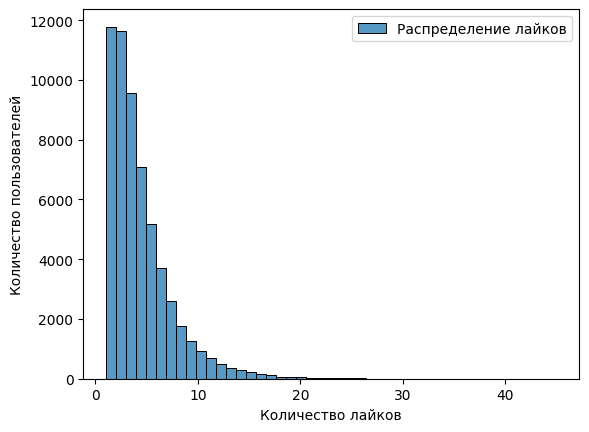

In [44]:
sns.histplot(data=df_likes_users.values, bins=df_likes_users.max(), label='Распределение лайков')

plt.xlabel('Количество лайков')
plt.ylabel('Количество пользователей')

plt.legend()
plt.show()

Разобьем пользователей, которые поставили лайк на 2 группы. И применим для групп статистический критерий Манна-Уитни-Уилкоксона (Данные далеко не нормальные, поэтому используем этот критерий).

In [50]:
df_likes_users = df_likes_users.reset_index().rename(columns={'post_id': 'likes'})
df_likes_users.head()

,user_id,likes
0,200,1
1,201,3
2,202,2
3,212,4
4,213,7


In [51]:
# Разбиваем таблицу на обе группы
df_likes_users_control = df_likes_users[df_likes_users['user_id'].isin(control_users)]
df_likes_users_test = df_likes_users[df_likes_users['user_id'].isin(test_users)]

# np Array с количество лайков в каждой группе
control_likes = df_likes_users_control['likes'].values
test_likes = df_likes_users_test['likes'].values

Посмотрим распределение лайков обоих групп на гистограмме.

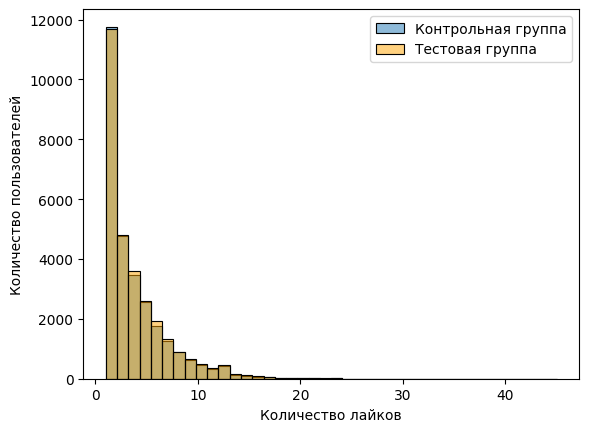

In [55]:
mx, mn = df_likes_users['likes'].max(), df_likes_users['likes'].min()

bins = np.linspace(mn, mx, 41)

sns.histplot(data=control_likes, bins=bins, alpha=0.5, label='Контрольная группа')
sns.histplot(data=test_likes, bins=bins, alpha=0.5, color='orange', label='Тестовая группа')

plt.xlabel('Количество лайков')
plt.ylabel('Количество пользователей')

plt.legend()
plt.show()

#### Применяем критерий

Применяем критерий. Уровень значимости 0.05

In [48]:
from scipy.stats import mannwhitneyu

_, p_value = mannwhitneyu(control_likes, test_likes)

print(f"p-value: {p_value}")

p-value: 0.0016817776764960254


P-value < 0.05. Критерий утверждает альт гипотезу, а значит выборки отличаются. Проверим какая лучше, используем среднее. (Среднее, так как данные принимают большое количество малых значений)

In [47]:
mean_control_likes = np.mean(control_likes)
mean_test_likes = np.mean(test_likes)

print(f'Медиана контрольной группы: {mean_control_likes}')
print(f'Медиана тестовой группы: {mean_test_likes}')

Медиана контрольной группы: 3.9122910452937503
Медиана тестовой группы: 3.999931817407016


Критерий подтвердил, что тестовая группа лучше.

### Тест №2. Какая модель давала более точные рекомендации

#### Формируем метрику

посчитаем **hitrate** (или долю рекомендаций, в которые пользователи кликнули). Для этого мы хотим собрать в одной табличке информацию о показанных постах и соответствующих кликах.

Сделать join по пользователям всех лайков и всех показов рекомендаций (то есть у нас появятся пары всех показов и всех лайков одного и того же пользователя, но не все эти пары реальны). Далее отфильтровать те ситуации, где лайк предшествовал показу рекомендаций (то есть относился на самом деле к другому показу) или был слишком поздно (тоже относится к другому показу). Время окна для правдивой записи - 1 час (То есть, если лайк был сделан позже на этот пост, то мы не считаем такую рекомендацию успешной).

In [142]:
# Мерджим данные
df = pd.merge(df_views, df_likes, how='left', on='user_id')

# Переименовыем колонки для удобства
df = df.rename(columns={
    'timestamp_x': 'date_rec',
    'timestamp_y': 'date_like',
    'post_id': 'like_post_id'
})
df.head()

,user_id,exp_group,recommendations,date_rec,like_post_id,date_like
0,128381,control,[3644 4529 4704 5294 4808],1654030803,4704.0,1.654031e+09
1,128381,control,[3644 4529 4704 5294 4808],1654030803,5294.0,1.654031e+09
2,128381,control,[3644 4529 4704 5294 4808],1654030803,3608.0,1.655049e+09
3,128381,control,[3644 4529 4704 5294 4808],1654030803,2542.0,1.655049e+09
4,128381,control,[3644 4529 4704 5294 4808],1654030803,4165.0,1.655053e+09


In [143]:
# Переводим даты из unit в обычную
df['date_rec'] = pd.to_datetime(df['date_rec'], unit='s')
df['date_like'] = pd.to_datetime(df['date_like'], unit='s')

print(f'Количество записей: {df.shape[0]}')
df.head()

Количество записей: 1016889


,user_id,exp_group,recommendations,date_rec,like_post_id,date_like
0,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04
1,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38
2,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,3608.0,2022-06-12 15:55:27
3,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,2542.0,2022-06-12 15:55:42
4,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,4165.0,2022-06-12 16:53:26


Отбираем валидные рекомендации.

In [144]:
# Фильтруем, чтобы дата рекомендации была раньше, чем лайк
df_recs = df[df['date_rec'] < df['date_like']]

print(f'Количество записей: {df_recs.shape[0]}')
df_recs.head()

Количество записей: 617537


,user_id,exp_group,recommendations,date_rec,like_post_id,date_like
0,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04
1,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38
2,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,3608.0,2022-06-12 15:55:27
3,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,2542.0,2022-06-12 15:55:42
4,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,4165.0,2022-06-12 16:53:26


In [145]:
# Фильтруем, чтобы дата рекомендации была раньше часа, чем был сделан лайк
df_recs = df_recs[(df_recs['date_like'] - df_recs['date_rec']) < pd.Timedelta(minutes=60)]

print(f'Количество записей: {df_recs.shape[0]}')
df_recs.head()

Количество записей: 232477


,user_id,exp_group,recommendations,date_rec,like_post_id,date_like
0,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04
1,128381,control,[3644 4529 4704 5294 4808],2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38
7,146885,test,[1399 1076 797 7015 5942],2022-05-31 21:00:11,1399.0,2022-05-31 21:00:16
11,50948,test,[2315 3037 1861 6567 4093],2022-05-31 21:00:25,2315.0,2022-05-31 21:00:28
16,37703,test,[2842 1949 162 1588 6794],2022-05-31 21:00:26,1588.0,2022-05-31 21:00:33


In [146]:
df_recs = df_recs.reset_index(drop=True)

Данные отфильтрованы. Теперь можно предполагать, что рекомендация могла повлиять на лайк поста. Теперь нужно:
1. Разделить `recommendations` на 5 разных колонок.
2. Добавить бинарную колонку `is_like`, где 1 - лайк рекомендованного поста.

Колонка `is_like` нужна будет для подсчета **hitrate**

In [147]:
"""
    Идем по колонки рекомендации. Сначала убираем первый и последний знак (Это знак '[]'), затем сплитим
    по пробелу. И переводим строку в число. Таким образом, получается список списков из 5 рекомендаций
"""
recs_list = [list(map(int, x[1:-1].split())) for x in df_recs['recommendations'].tolist()]
print(len(recs_list))
print(recs_list[:3])

df_five_recs = pd.DataFrame(recs_list, columns=['recs_1', 'recs_2', 'recs_3', 'recs_4', 'recs_5'])
df_five_recs.head()

232477
[[3644, 4529, 4704, 5294, 4808], [3644, 4529, 4704, 5294, 4808], [1399, 1076, 797, 7015, 5942]]


,recs_1,recs_2,recs_3,recs_4,recs_5
0,3644,4529,4704,5294,4808
1,3644,4529,4704,5294,4808
2,1399,1076,797,7015,5942
3,2315,3037,1861,6567,4093
4,2842,1949,162,1588,6794


Конкатенируем с таблицей и убираем прошлый столбец.

In [148]:
df_recs = pd.concat([df_recs, df_five_recs], axis=1)
df_recs = df_recs.drop(columns=['recommendations',])

df_recs.head()

,user_id,exp_group,date_rec,like_post_id,date_like,recs_1,recs_2,recs_3,recs_4,recs_5
0,128381,control,2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04,3644,4529,4704,5294,4808
1,128381,control,2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38,3644,4529,4704,5294,4808
2,146885,test,2022-05-31 21:00:11,1399.0,2022-05-31 21:00:16,1399,1076,797,7015,5942
3,50948,test,2022-05-31 21:00:25,2315.0,2022-05-31 21:00:28,2315,3037,1861,6567,4093
4,37703,test,2022-05-31 21:00:26,1588.0,2022-05-31 21:00:33,2842,1949,162,1588,6794


Формируем колонку `is_like`

In [149]:
rec_cols = ['recs_1', 'recs_2', 'recs_3', 'recs_4', 'recs_5']

df_recs['is_like'] = df_recs.apply(
    lambda row: row['like_post_id'] in row[rec_cols].values,
    axis=1
)

df_recs.head()

,user_id,exp_group,date_rec,like_post_id,date_like,recs_1,recs_2,recs_3,recs_4,recs_5,is_like
0,128381,control,2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04,3644,4529,4704,5294,4808,True
1,128381,control,2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38,3644,4529,4704,5294,4808,True
2,146885,test,2022-05-31 21:00:11,1399.0,2022-05-31 21:00:16,1399,1076,797,7015,5942,True
3,50948,test,2022-05-31 21:00:25,2315.0,2022-05-31 21:00:28,2315,3037,1861,6567,4093,True
4,37703,test,2022-05-31 21:00:26,1588.0,2022-05-31 21:00:33,2842,1949,162,1588,6794,True


Теперь посчитаем общий **hitrate**

In [150]:
df_recs.groupby('exp_group')['is_like'].mean()

exp_group
control    0.989909
test       0.989976
Name: is_like, dtype: float64

#### Применяем критерий

Так как, hitrate это общая метрика, то применим бакетирование. Сформируем 100 бакетов и применим критерий на распределение бакетов.

In [152]:
df_recs_control = df_recs[df_recs['user_id'].isin(control_users)]
df_recs_test = df_recs[df_recs['user_id'].isin(test_users)]

print(f'Размеры: Контрольная - {df_recs_control.shape[0]} | Тестовая - {df_recs_test.shape[0]}')

Размеры: Контрольная - 113958 | Тестовая - 118519


In [153]:
from hashlib import md5

# Кол-во бакетов
n_bucket = 100

# Формируем бакеты, с помощью разбиения по соли
salt = 'unique_salt'

df_recs['bucket'] = df_recs['user_id'].apply(
    lambda x: int(md5((str(x) + salt).encode()).hexdigest(), 16) % n_bucket
)

df_recs.head()

,user_id,exp_group,date_rec,like_post_id,date_like,recs_1,recs_2,recs_3,recs_4,recs_5,is_like,bucket
0,128381,control,2022-05-31 21:00:03,4704.0,2022-05-31 21:00:04,3644,4529,4704,5294,4808,True,47
1,128381,control,2022-05-31 21:00:03,5294.0,2022-05-31 21:00:38,3644,4529,4704,5294,4808,True,47
2,146885,test,2022-05-31 21:00:11,1399.0,2022-05-31 21:00:16,1399,1076,797,7015,5942,True,60
3,50948,test,2022-05-31 21:00:25,2315.0,2022-05-31 21:00:28,2315,3037,1861,6567,4093,True,0
4,37703,test,2022-05-31 21:00:26,1588.0,2022-05-31 21:00:33,2842,1949,162,1588,6794,True,32


Группируем данные по группе и бакету

In [154]:
df_analyze = df_recs.groupby(['exp_group', 'bucket'])['is_like'].mean().reset_index()

df_analyze.head()

,exp_group,bucket,is_like
0,control,0,0.988372
1,control,1,0.991828
2,control,2,0.997090
3,control,3,0.992410
4,control,4,0.989820


Распределение бакетов

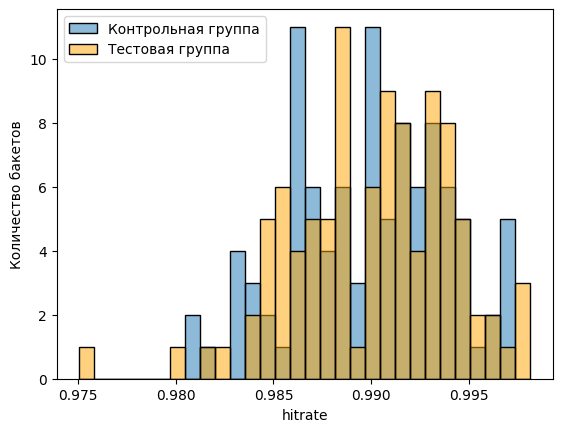

In [155]:
control_group = df_analyze[df_analyze['exp_group'] == 'control']['is_like'].values
test_group = df_analyze[df_analyze['exp_group'] == 'test']['is_like'].values

mx, mn = df_analyze['is_like'].max(), df_analyze['is_like'].min()

bins = np.linspace(mn, mx, 31)

sns.histplot(data=control_group, bins=bins, alpha=0.5, label='Контрольная группа')
sns.histplot(data=test_group, bins=bins, alpha=0.5, color='orange', label='Тестовая группа')

plt.xlabel('hitrate')
plt.ylabel('Количество бакетов')

plt.legend()
plt.show()

Применяем критерий Манна-Уитни-Уилкоксона. Уровень значимости 0.05

In [156]:
from scipy.stats import mannwhitneyu

_, p_value = mannwhitneyu(control_group, test_group)

print(f"p-value: {p_value}")

p-value: 0.8088607857634111


Уровень значимости > 0.05. Значит что между группами разницы нет. 

### Выводы

Первый тест показал на значимость новой модели. Пользователи с этой моделью сделали больше лайков, чем пользователи с старой моделью.

Второй тест показал, что статистической разницы в моделях нету. Обе модели давали рекомендации с почти одинаковой метрикой.

Метрика для второго теста более справедлива, так как учитывает именно взаимодействие модели с пользователем. Следовательно, можно сделать вывод, что второй тест более честный.

Значит, мы утверждаем, что статистической разницы между моделями нету.